# Siglip2  From Scratch

Gerçekleştirilen çalışma tememlde Siglip v1 mimarisinin aynısıdır fakat burada eğitim stratejisinde farklılıklar yapmışlardır. Bu kapsamda;

    1- Self Distillation -> Traditional Knowledge Distilattion(KD) işleminde student(küçük) ve teacher(büyük) model olmak üzere 2 farklı model olur ve eğitim işlemi esnasında student modelin olasılıksal çıktıları teacher modele yaklaştırmak amacıyla KL Divergence gibi losslar kullanılmaktadır. Fakat DINO makalesinde self distillation adı altında yeni bir yaklaşım öne sürdüler. Bu yaklaşımda klasik student teacher olmak üzere 2 farklı model yerine aynı modeli kullanım sadece teacherin parametrelerini güncellerken Exponential Moving Average(θt = m θt + (1 - m) θs) yani teacher modelin gradientlerini güncellerken daha yavaş adımlarla studenta göre güncellenmişlerdir. Bu sayede student modeli hızlı değişim gösterirken teacher daha slow ve smooth olmaktadır. Bu yaklaşım sayesinde modelin local objectiveness, patch semantic ve spatial understanding, localisation gibi temel özellikleri artmış ve bu durum OCR gibi tasklarda başarılarını artırmıştır.

    2-) Masked Prediction : Masked AutoEncoder makalesinde büyük modelleri train etmeden önce transfer learning yapabilmek için input image de bazı bölümler maskelenerek modelin çıktısında oılmayan bölümlerin tahmininin yapılması istenmekteydi. Bu çalışmada ise Self Distillation ile bu yaklaşımı birleştirilererek, teacher modele tüm görüntü verilirken student modele corrupt edilmiş görüntü verilmektedir. Ardından student model teacher modele yaklaştırılcağından student modelin local bileşenlerdeki başarısı dahada artırılmaktadır.

    3-) Auto Regressive Decoder : Buradaki amaç klasik LLM modellerinde çıktı oluşturulurken adım adım bir önceki girdiler verilerek oluşturmaktaydı burada da relatively small transformer model kullanılarak bir decoder oluşturulmuştur. Bu decoder vasıtasıyla verilen görüntü üzerinden, görüntüye ilişkin textin oluşturulması amaçlanmıştır. Klasik Cross Attention mantığında düşünebiliriz İmage encoder tarafından queryler geliyor decoder tarafında value ve key arasında ilişki kurularak ilgili querye göre çıktı oluşmaktadır. Klasik CLIP mimarisinde modelin text ile image eşleştirmesi amaçlanmaktaydı bu durum eğitim işlemi esnasında modelin lazy shortcutları öğrenmesine neden olmasına sebep olmaktadır böylece komple objeyi öğrenmek yerine daha basit bileşenleri eşleştirmek için öğrenmekteydi. Bu kapsamda SigLip-2 çalışmasında da Locca(Location Aware Caption) loss'u kullanılmıştır yani AR decoder tarafından oluşturulan çıktılarında loss'a etki etmesini sağlayarak image encoder ve text encoderin daha iyi öğrenmesini sağlamışlardır. AR decoder tarafında task olarak ise görüntüde ne olduğu, hangi objenğn nerede olduğu vb. farklı tasklarda eğitim işlemi yapılarak başarı artırılmıştır.

    4-) LogSigmoid Loss : Detaylı anlatımı implementasyonda mevcut.

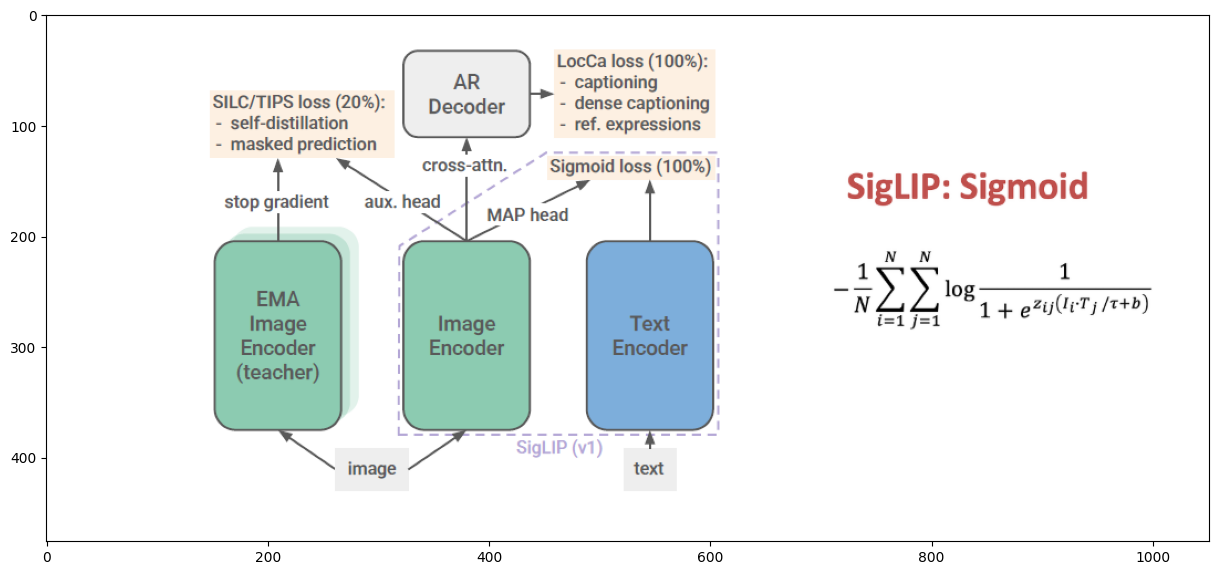

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread("siglip_arch.png"), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,15))
plt.imshow(img)
plt.show()

In [67]:
import torch
import torch.nn as nn
from einops import rearrange
from easydict import EasyDict
import torch.nn.functional as F
from transformers.modeling_outputs import BaseModelOutput, BaseModelOutputWithPooling

config = EasyDict(
    {
        "vocab_size" : 256_000,
        "hidden_dim" : 768,
        "num_hidden_layers" : 12,
        "intermediate_dim" : 3072,
        "projection_size" : 768,
        "max_position_embedding" : 64,
        "num_attention_heads" : 12,
        "vision_use_heads" : False,
        "attention_dropout" : 0.0,
        "attn_implementation" : "sdpa",
        "num_channels" : 3,
        "patch_size" : 16,
        "image_size" : 224,
        "layer_norm_eps" : 1e-6
    }
)

class SiglipTextEmbedding(nn.Module):
    """
    Text Input -> Token Embedding + Position Embedding -> Output
    """
    def __init__(self, config):
        super(SiglipTextEmbedding, self).__init__()

        self.token_embed = nn.Embedding(num_embeddings=config.vocab_size, embedding_dim=config.hidden_dim) #256000,768

        self.pos_embed = nn.Embedding(num_embeddings=config.max_position_embedding, embedding_dim=config.hidden_dim) # 64,768

        self.register_buffer("position_ids", torch.arange(config.max_position_embedding).unsqueeze(0), persistent=False) # 64

    def forward(self, input_ids, position_ids=None, input_embeds=None):
        seq_length = input_ids.shape[-1] if input_ids is not None else input_embeds.shape[-2]

        if seq_length > self.pos_embed.weight.shape[0]:
            raise ValueError("Sequence length must be less than max_position_embeddings->64")

        pos_embed = self.pos_embed(position_ids) if position_ids is not None else self.pos_embed(self.position_ids[:, :seq_length]) # 1,T,768

        input_embeds = self.token_embed(input_ids) if input_embeds is None else input_embeds 

        embeddings = input_embeds + pos_embed # B,T,De

        return embeddings


class SiglipVisionEmbeddings(nn.Module):
    """
    Input -> Patch Embedding + Position Embedding -> Out
    """
    def __init__(self, config):
        super(SiglipVisionEmbeddings, self).__init__()

        self.patch_size = config.patch_size
        
        self.num_patches = (config.image_size // config.patch_size)**2
        
        self.num_positions = self.num_patches

        self.patch_embed = nn.Conv2d(in_channels=config.num_channels, out_channels=config.hidden_dim, kernel_size=config.patch_size,
                                     stride=config.patch_size, padding="valid") # Valid means no padding like padding=0

        self.pos_embed = nn.Embedding(num_embeddings=self.num_patches, embedding_dim=config.hidden_dim) # 196,768

        self.register_buffer("position_ids", torch.arange(self.num_patches).unsqueeze(0), persistent=False) # 1,196

    def forward(self, x, interpolate_pos_encodings=True):
        B, C, H, W = x.shape

        x = rearrange(self.patch_embed(x), "B C Nh Nw  -> B (Nh Nw) C") # B,196,768

        x = x + self.interpolate_pos_encodings(x, H, W) if interpolate_pos_encodings else x + self.pos_embed(self.position_ids)

        return x

    def interpolate_pos_encodings(self, x, H, W):
        "Bicubic Interpolation for different Image input sizes"
        input_num_patches, num_patches = x.shape[1], self.num_patches

        if not torch.jit.is_tracing() and input_num_patches == num_patches and H == W:
            # Trace edilmediyse tracing False Döner, bu kısım boyutlar aynıysa doğrudan interpolasyona gerek yok
            return self.pos_embed(self.position_ids) 
            
        Nh_, Nw_ = H // self.patch_size, W // self.patch_size

        sqrt_num_patches = int(self.num_patches ** 0.5)
        
        patch_pos_embed = self.pos_embed.weight.unsqueeze(0) # 1,196,768

        patch_pos_embed = rearrange(patch_pos_embed, "B (Nh Nw) De -> B De Nh Nw", Nh=sqrt_num_patches, Nw=sqrt_num_patches) # B,768,14,14

        patch_pos_embed = F.interpolate(patch_pos_embed, size=(Nh_, Nw_), mode="bicubic", align_corners=False) # B,768,Nh,Nw ->Interpolated

        patch_pos_embed = rearrange(patch_pos_embed, "B C H W -> B (H W) C") # B,Nh*Nw,C

        return patch_pos_embed


class SiglipMLP(nn.Module):
    """
    Input -> MLP -> Gelu(approx tanh) -> MLP -> Output (For Future Swigglu better)
    """
    def __init__(self, config):
        super(SiglipMLP, self).__init__()

        self.act = nn.GELU(approximate="tanh")

        self.fc1 = nn.Linear(in_features=config.hidden_dim, out_features=config.intermediate_dim)

        self.fc2 = nn.Linear(in_features=config.intermediate_dim, out_features=config.hidden_dim)

    def forward(self, x):
        out = self.fc2(self.act(self.fc1(x))) # B,T,De

        return out


class SiglipAttention(nn.Module):
    """
    Input -> Q,K,V Linear -> softmax(Q @ K.T / head_dim) @ value -> Linear -> Out
    """
    def __init__(self, config):
        super(SiglipAttention, self).__init__()

        self.attn_type = config.attn_implementation

        self.dropout = config.attention_dropout
        
        self.num_heads = config.num_attention_heads
        
        self.head_dim = config.hidden_dim // config.num_attention_heads
        
        self.scale = self.head_dim ** -0.5

        self.key = nn.Linear(in_features=config.hidden_dim, out_features=config.hidden_dim)

        self.value = nn.Linear(in_features=config.hidden_dim, out_features=config.hidden_dim)

        self.query = nn.Linear(in_features=config.hidden_dim, out_features=config.hidden_dim)

        self.out_proj = nn.Linear(in_features=config.hidden_dim, out_features=config.hidden_dim)


    def forward(self, x, attention_mask=None):
        q = rearrange(self.query(x), "B T (He De) -> B He T De", He=self.num_heads) # B,He,T,De

        k = rearrange(self.key(x), "B T (He De) -> B He T De", He=self.num_heads) # B,He,T,De

        v = rearrange(self.value(x), "B T (He De) -> B He T De", He=self.num_heads) # B,He,T,De

        if self.attn_type == "eager":
            attn_weights = (q @ k.transpose(-1, -2)) * self.scale # B,He,T,T
    
            if attention_mask is not None:
                attn_weights += attention_mask
    
            attn_weights = attn_weights.softmax(dim=-1, dtype=torch.float32).to(q.dtype) # B,He,T,T
    
            attn_weights = F.dropout(attn_weights, p=self.dropout, training=self.training)
    
            out = rearrange(attn_weights @ v, "B He T De -> B T (He De)") # B,T,De
    
            out = self.out_proj(out)
        else:
            attn_weights = None 
            
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=attention_mask, dropout_p=self.dropout if self.training else 0.0,
                                                 is_causal=False, scale=self.scale)
            out = self.out_proj(rearrange(out, "B He T De -> B T (He De)"))
    
        return out, attn_weights


class SiglipEncoderLayer(nn.Module):
    """
    Input -> Pre Norm -> Self Attention -> Adding ->  Post Norm -> Mlp -> Adding -> Out 
    """
    def __init__(self, config):
        super(SiglipEncoderLayer, self).__init__()

        self.pre_norm = nn.LayerNorm(config.hidden_dim, eps=config.layer_norm_eps)

        self.attn = SiglipAttention(config)

        self.post_norm = nn.LayerNorm(config.hidden_dim, eps=config.layer_norm_eps)

        self.mlp = SiglipMLP(config)

    def forward(self, x, attention_mask):
        x = self.attn(self.pre_norm(x))[0] + x # B,T,De

        x = self.mlp(self.post_norm(x)) + x # B,T,De

        return x


class SiglipMultiHeadAttentionPoolingHead(nn.Module):
    """
    Using for Summarizing All Patches into One Vector, bu işlemi yaparken Query Embedding parameteresi tasarlayıp ardından vektörü summarize etmek
    için verilen bu query ile embedding vektör attention işlemine maruz kalarak çıktı elde edilecke bu sayede clasification, similarity gibi tasklarda
    kullanılabilir.
    """
    def __init__(self, config):
        super(SiglipMultiHeadAttentionPoolingHead, self).__init__()

        self.probe = nn.Parameter(torch.randn(1, 1, config.hidden_dim)) # 1,1,De

        self.attention = nn.MultiheadAttention(embed_dim=config.hidden_dim, num_heads=config.num_attention_heads, batch_first=True)

        self.norm = nn.LayerNorm(config.hidden_dim, eps=config.layer_norm_eps)

        self.mlp = SiglipMLP(config)

    def forward(self, x):
        B, T, De = x.shape

        probe = self.probe.repeat(B, 1, 1) # B,T,De

        x = self.attention(probe, x, x)[0] # Cross Attention -> B,1,768, B,T,768 -> B,1,De

        x = self.mlp(self.norm(x)) + x # B,1,De

        return x[:, 0, :] # B,De


class SiglipEncoder(nn.Module):
    """
    Input -> N x SiglipEncoderLayer -> Output
    """
    def __init__(self, config):
        super(SiglipEncoder, self).__init__()

        self.layers = nn.ModuleList([SiglipEncoderLayer(config) for _ in range(config.num_hidden_layers)])

        self.gradient_checkpoint = False

    def forward(self, x, attention_mask=None):
        """Huggingface Like Output ->  {"last_hidden_state":x} """
        for layer in self.layers:
            x = layer(x, attention_mask) # B,T,De
            
        return BaseModelOutput(last_hidden_state=x) # B,T,De


class SiglipTextModel(nn.Module):
    """
    Input -> Text Embedding -> Transformer Encoder -> Output
    """
    def __init__(self, config):
        super(SiglipTextModel, self).__init__()

        self.embeddings = SiglipTextEmbedding(config)

        self.encoder = SiglipEncoder(config)

        self.final_norm = nn.LayerNorm(config.hidden_dim, eps=config.layer_norm_eps)

        self.head = nn.Linear(in_features=config.hidden_dim,  out_features=config.projection_size)

    def forward(self, input_ids, attention_mask=None, position_ids=None):
        x = self.embeddings(input_ids, position_ids) # B,T,768

        attention_mask = self.create_mask(x, attention_mask) # B,1,T,T

        x = self.encoder(x, attention_mask) # B,T,De

        x = self.final_norm(x.last_hidden_state) # B,T,De

        pooler_output = self.head(x[:, -1, :]) #B,De -> Text model use only last token

        return BaseModelOutputWithPooling(last_hidden_state=x, pooler_output=pooler_output)
        
    def create_mask(self, x, attention_mask):
        """
        Full Bidirectional Attention Mask yani causal gibi masklama işlemi yapmana gerek yok
        """
        B, T, De = x.shape

        mask = torch.ones((B, 1, T, T), dtype=torch.bool, device=x.device)

        if attention_mask is not None:
            padding_mask = attention_mask[:, None, None, :].bool()

            mask = mask & padding_mask

        return mask


class SiglipVisionModel(nn.Module):
    """
    Input -> Patch Embedding -> Transformer Encoder -> MultiHeadAttentionPooling Head
    """
    def __init__(self, config):
        super(SiglipVisionModel, self).__init__()

        self.patch_embedding = SiglipVisionEmbeddings(config)

        self.encoder = SiglipEncoder(config)

        self.final_norm = nn.LayerNorm(config.hidden_dim, eps=config.layer_norm_eps)

        self.use_head = True if not config.vision_use_heads else config.vision_use_heads

        if self.use_head:
            self.head = SiglipMultiHeadAttentionPoolingHead(config)

    def forward(self, x, interpolate_pos_encodings=False):
        x = self.patch_embedding(x, interpolate_pos_encodings) # B,H*W/14*14,De

        x = self.encoder(x) # B,H*W/14*14,De

        x = self.final_norm(x.last_hidden_state) # B,H*W/14*14,De

        pooler_output = self.head(x) if self.use_head else None #B,De

        return BaseModelOutputWithPooling(last_hidden_state=x, pooler_output=pooler_output)
    

class SiglipModel(nn.Module):
    """
    Input -> Text Model -> Vision Model -> Cos Sim(Image ,Text) * scale + bias -> Output
    """
    def __init__(self, config):
        super(SiglipModel, self).__init__()

        self.text_model = SiglipTextModel(config)

        self.vision_model = SiglipVisionModel(config)

        self.logit_scale = nn.Parameter(torch.randn(1))

        self.logit_bias = nn.Parameter(torch.randn(1))

    def forward(self, input_ids, pixel_values, attention_mask=None, position_ids=None, return_loss=None, interpolate_pos_encodings=False):
        vision_outputs = self.vision_model(pixel_values, interpolate_pos_encodings) # B,196,De / B,De

        text_outputs = self.text_model(input_ids, attention_mask, position_ids) # B,T,De / B,De

        image_embeds = vision_outputs.pooler_output # B,De

        text_embeds = text_outputs.pooler_output # B,De

        image_embeds = image_embeds  / image_embeds.norm(p=2, dim=-1, keepdim=True) # B,De / B,1 -> B,De -> L2 Norm

        text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

        # CosΘ = A.B / |A| |B|
        cos_sim = text_embeds @ image_embeds.transpose(-1, -2) # B,De @ De,B -> B,B

        logit_scale, logit_bias = self.logit_scale.to(cos_sim.device), self.logit_bias.to(cos_sim.device)  # 1, 1

        logits_per_text_sim = cos_sim * logit_scale.exp() + logit_bias # B,B

        logits_per_img_sim = logits_per_text_sim.T

        return {"logits_per_image":logits_per_img_sim, "logits_per_text":logits_per_text_sim, "text_embeds":text_embeds, 
                "image_embeds":image_embeds, "text_model_output":text_outputs, "vision_model_output":vision_outputs}
        
    def get_input_embeddings(self):
        return self.text_model.embeddings.token_embed

    def set_input_embeddings(self, value):
        self.text_model.embeddings.token_embed = value

    def get_text_features(self, input_ids, attention_mask=None, position_ids=None):
        return self.text_model(input_ids, attention_mask, position_ids)

    def get_image_features(self, x, interpolate_pos_encodings=False):
        return self.vision_model(x, interpolate_pos_encodings)

    def get_loss(self, logits_per_text):
        """                     
                                  1 0 0                        1  -1  -1
        Siglip Sigmoid Loss ->    0 1 0  -> 2 * eye - ones -> -1   1  -1  -> log(sigmoid(logit * mask)) ->Summation-> Sample Baed Mean
                                  0 0 1                       -1  -1   1

        Amaç Diagonel elemanları sonsuz yani oldukça büyük yapıp  sigmoid çıktısı 1'e ulaşırken diğerlerini  -sonsuza yani oldukça küçük yapar. Burada
        eye matrisi -1 * -sonsuz = + sonsuz 1/1+e^-x = 1 log1 = 0 olur böylece sigmoid sonucu sıfır çıkar. Log alınıncınca 1 elemanları loss
        getirmezken diğerleri getirir.
        """
        eye_mtx = torch.eye(logits_per_text.shape[0], device=logits_per_text.device) # T,T

        labels = 2 * eye_mtx - torch.ones_like(eye_mtx) # Diagonel 1 other elements value -1

        log_sigmoid = torch.log(F.sigmoid(labels * logits_per_text) + 1e-6)  # T,T -> F.logsigmoid(labels * logits_per_text)

        loss = -(log_sigmoid.sum(dim=-1)).mean()

        return loss

image_tensor = torch.randn(3,3,224,224)

text_tensor = torch.randint(low=0, high=5, size=(3,64))    

model = SiglipModel(config)

model.load_state_dict(torch.load("siglip2_base_patch16_224.pth"))

<All keys matched successfully>

In [68]:
model.get_loss(model(text_tensor, image_tensor)["logits_per_text"])

tensor(9.6801, grad_fn=<NegBackward0>)

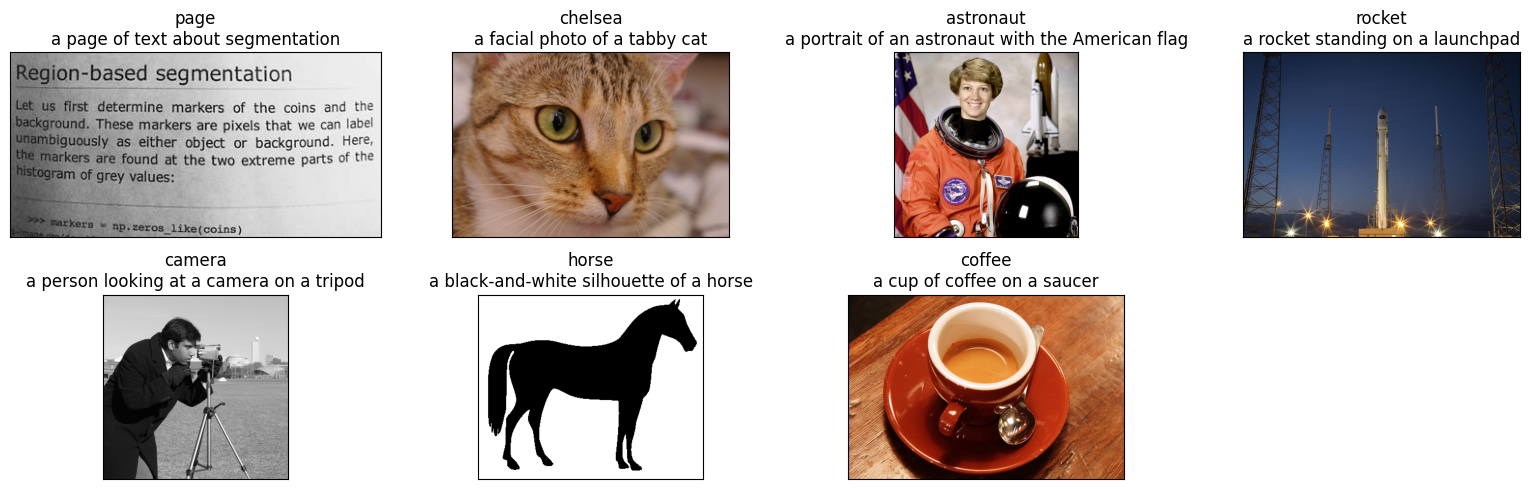

In [69]:
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from torchvision import transforms

tokenizer = AutoTokenizer.from_pretrained("tokenizer_folder")

image_transform = transforms.Compose([transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BILINEAR),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

descriptions = {
    "page": "a page of text about segmentation",
    "chelsea": "a facial photo of a tabby cat",
    "astronaut": "a portrait of an astronaut with the American flag",
    "rocket": "a rocket standing on a launchpad",
    "camera": "a person looking at a camera on a tripod",
    "horse": "a black-and-white silhouette of a horse",
    "coffee": "a cup of coffee on a saucer"
}

image_loaders = {
    "page": data.page,
    "chelsea": data.chelsea,
    "astronaut": data.astronaut,
    "rocket": data.rocket,
    "camera": data.camera,
    "horse": data.horse,
    "coffee": data.coffee
}

original_images = []
texts = []

plt.figure(figsize=(16, 5))

for i, (name, loader) in enumerate(image_loaders.items()):
    image_array = loader()

    if image_array.ndim == 2:
        image = Image.fromarray(image_array).convert("RGB")
    else:
        image = Image.fromarray(image_array)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"{name}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)

    texts.append("This is " + descriptions[name])

plt.tight_layout()
plt.show()

pixel_values = torch.stack([image_transform(img) for img in original_images ])

text_tokens = tokenizer(texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")

with torch.no_grad():

    image_features = model.get_image_features(pixel_values).pooler_output

    text_features = model.get_text_features(text_tokens["input_ids"]).pooler_output

image_features = F.normalize(image_features, p=2, dim=-1)

text_features = F.normalize(text_features,p=2, dim=-1)

similarity_scores = text_features @ image_features.T


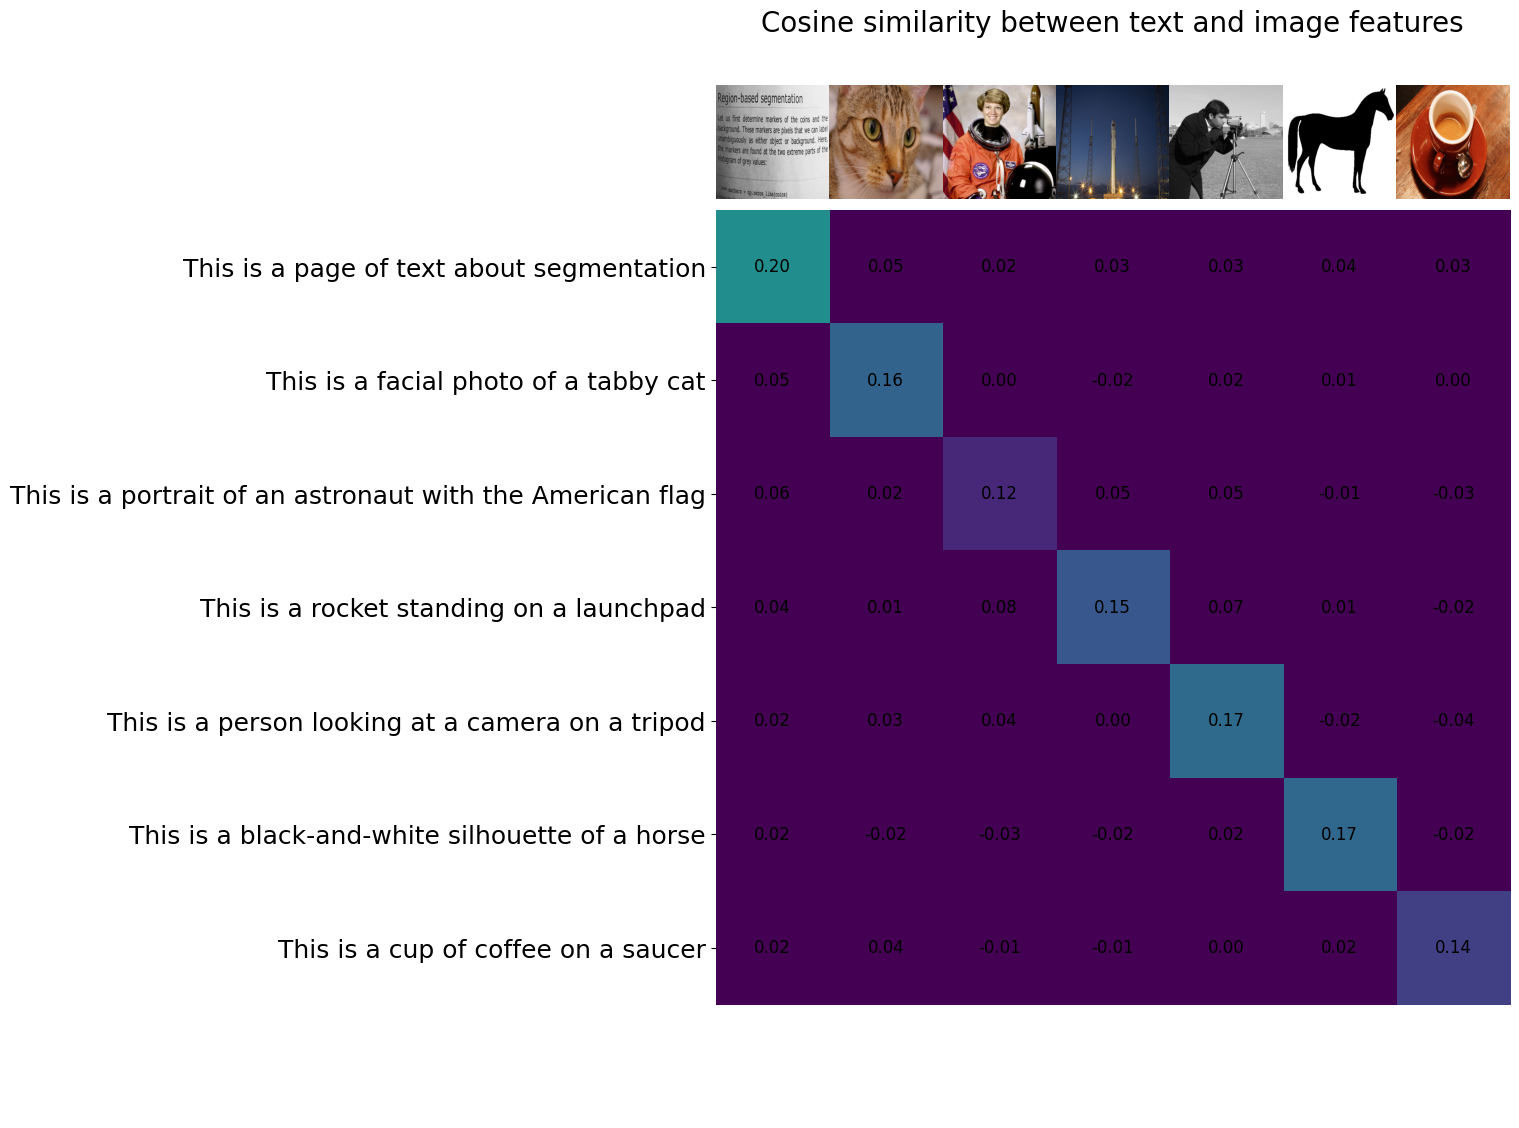

In [70]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity_scores.detach().cpu(), vmin=0.1, vmax=0.3)

plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])

for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
    
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)
plt.show()

# Google Model Weight To Our ModelTransfer

import torch
from transformers import AutoModel, AutoProcessor
from transformers.image_utils import load_image

# load the model and processor
ckpt = "google/siglip2-base-patch16-224"
org_model = AutoModel.from_pretrained(ckpt, device_map="auto").eval()

model = SiglipModel(config)

for (org_name, org_param), (new_name, new_param) in zip(org_model.named_parameters(), model.named_parameters()):
  new_param.data.copy_(org_param.data)


torch.save(model.state_dict(), "siglip2_base_patch16_224.pth")